# W5 — Comparative Analysis: CPQ-IQL vs Baselines
## Safe Offline Reinforcement Learning for Sepsis Treatment

---

This notebook  produces a **comparative analysis** of five methods:

| Method | Description |
|--------|-------------|
| **Random** | Uniform action sampling — lower-bound sanity check |
| **DQN** | Offline Deep Q-Network — no distribution-shift mitigation |
| **IQL** | Implicit Q-Learning — state-of-the-art unconstrained backbone |
| **CQL** | Conservative Q-Learning (Tu et al., 2025) |
| **CPQ-IQL** | Our method — constrained pessimistic Q-learning + Safe Actions filter |
| **CPQ-IQL (Stage 1)** | CPQ-IQL without Safe Actions filter — isolates Stage 1 contribution |

### Metrics
| Metric | Symbol | Direction | Description |
|--------|--------|-----------|-------------|
| Total CVR | CVR ↓ | ↓ | Primary safety metric |
| Per-constraint CVR | C1–C4 ↓ | ↓ | Safety decomposition |
| Safe CVR | SafeCVR ↓ | ↓ | CVR after Stage 2 filter |
| Survival Rate | SR ↑ | ↑ | Patient-level clinical outcome |
| FQE value | V_FQE ↑ | ↑ | Offline policy value estimate |
| BC top-k | BC@k ↑ | ↑ | Clinician alignment |
| Intervention Rate | IR % | — | Stage 2 filter activity |




In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Paths ──────────────────────────────────────────────────────────────────
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NOTEBOOK_DIR = os.path.abspath('')
PROJECT_ROOT = os.path.join(NOTEBOOK_DIR, '..')
EXP_DIR      = os.path.join(PROJECT_ROOT, 'experiments')
FIG_DIR      = os.path.join(PROJECT_ROOT, 'figures', 'comparison')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 11,
    'legend.fontsize'  : 10,
    'figure.dpi'       : 120,
})

# ── Colour palette ─────────────────────────────────────────────────────────
METHOD_COLORS = {
    'Random'            : '#AAAAAA',
    'DQN'               : '#4393C3',
    'IQL'               : '#74C476',
    'CQL'               : '#FD8D3C',
    'CPQ-IQL (Stage 1)' : '#756BB1',
    'CPQ-IQL'           : '#9E2A2B',
}
CONSTRAINT_COLORS = ['#2C7BB6', '#FF7F00', '#7B2D8B', '#D7191C']
CONSTRAINT_NAMES  = ['C1 Hypotension', 'C2 Metabolic', 'C3 Cumulative', 'C4 Withdrawal']

SAVE_DPI = 200   # publication-quality

def savefig(name: str) -> None:
    """Save current figure to figures/comparison/."""
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=SAVE_DPI, bbox_inches='tight')
    print(f'  Saved → {path}')

print('Setup complete.')
print(f'Figures will be saved to: {os.path.abspath(FIG_DIR)}')


Setup complete.
Figures will be saved to: c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\comparison


---
## 1. Load Evaluation Artefacts

All results were pre-computed in W3 and W4 and serialised as JSON / CSV files.

In [2]:
# ── CPQ-IQL results (W3) ──────────────────────────────────────────────────
cpq_path = os.path.join(EXP_DIR, 'all_results.json')
with open(cpq_path) as f:
    cpq_raw = json.load(f)

# ── Baseline results (W4) ─────────────────────────────────────────────────
def _load_baseline(method):
    path = os.path.join(EXP_DIR, f'baselines_{method}.json')
    with open(path) as f:
        return json.load(f)

raw = {
    'Random'  : _load_baseline('random'),
    'DQN'     : _load_baseline('dqn'),
    'IQL'     : _load_baseline('iql'),
    'CQL'     : _load_baseline('cql'),
}

# ── Ablation table (W3) ───────────────────────────────────────────────────
abl_path = os.path.join(EXP_DIR, 'ablation_full.csv')
df_abl   = pd.read_csv(abl_path)

print('Loaded artefacts:')
for k, v in raw.items():
    print(f'  {k:<8} → experiments/baselines_{k.lower()}.json')
print(f'  CPQ-IQL  → experiments/all_results.json')
print(f'  Ablation → experiments/ablation_full.csv ({len(df_abl)} rows)')


Loaded artefacts:
  Random   → experiments/baselines_random.json
  DQN      → experiments/baselines_dqn.json
  IQL      → experiments/baselines_iql.json
  CQL      → experiments/baselines_cql.json
  CPQ-IQL  → experiments/all_results.json
  Ablation → experiments/ablation_full.csv (13 rows)


---
## 2. Unified Metrics Table

All methods are aggregated into a single DataFrame for downstream analysis.

In [14]:
def _extract(name, data, is_cpq=False):
    """Flatten nested result dict into a single-row dict."""
    if is_cpq:
        cvr  = data.get('cvr_rollout', {})
        safe = data.get('safe_actions', {})
        bc   = data.get('bc_accuracy',  {})
        sr   = data.get('survival_rate',{})
        fqe  = data.get('fqe',          {})
    else:
        cvr  = data.get('cvr_rollout', {})
        safe = data.get('safe_actions', {})
        bc   = data.get('bc_accuracy',  {})
        sr   = data.get('survival_rate',{})
        fqe  = data.get('fqe',          {})
    return {
        'Method'            : name,
        'CVR_%'             : cvr.get('total_cvr',       float('nan')) * 100,
        'C1_%'              : cvr.get('C1_hypotension',  float('nan')) * 100,
        'C2_%'              : cvr.get('C2_metabolic',    float('nan')) * 100,
        'C3_%'              : cvr.get('C3_cumulative',   float('nan')) * 100,
        'C4_%'              : cvr.get('C4_withdrawal',   float('nan')) * 100,
        'SafeCVR_%'         : safe.get('safe_total_cvr', float('nan')) * 100,
        'SafeC1_%'          : safe.get('safe_C1_hypotension', float('nan')) * 100,
        'SafeC2_%'          : safe.get('safe_C2_metabolic',   float('nan')) * 100,
        'SafeC3_%'          : safe.get('safe_C3_cumulative',  float('nan')) * 100,
        'SafeC4_%'          : safe.get('safe_C4_withdrawal',  float('nan')) * 100,
        'IR_%'              : safe.get('intervention_rate',   float('nan')) * 100,
        'BC_top1_%'         : bc.get('top1',  float('nan')) * 100,
        'BC_top3_%'         : bc.get('top3',  float('nan')) * 100,
        'BC_top5_%'         : bc.get('top5',  float('nan')) * 100,
        'BC_top1_norm_%'    : bc.get('top1_norm', float('nan')) * 100,
        'BC_top3_norm_%'    : bc.get('top3_norm', float('nan')) * 100,
        'SR_clinician_%'    : sr.get('sr_clinician', float('nan')) * 100,
        'SR_policy_%'       : sr.get('sr_policy',    float('nan')) * 100,
        'delta_SR_%'        : sr.get('delta_sr',     float('nan')) * 100,
        'CI_lo_%'           : sr.get('ci_lo',        float('nan')) * 100,
        'CI_hi_%'           : sr.get('ci_hi',        float('nan')) * 100,
        'V_FQE'             : fqe.get('v_fqe',  float('nan')),
        'delta_V'           : fqe.get('delta_v', float('nan')),
    }

rows = [_extract(k, v) for k, v in raw.items()]

# CPQ-IQL Stage 1 (no filter)
stage1_data = {
    'cvr_rollout'  : cpq_raw.get('cvr_rollout', {}),
    'safe_actions' : {},
    'bc_accuracy'  : cpq_raw.get('bc_accuracy', {}),
    'survival_rate': cpq_raw.get('survival_rate', {}),
    'fqe'          : cpq_raw.get('fqe', {}),
}
rows.append(_extract('CPQ-IQL (Stage 1)', stage1_data))

# CPQ-IQL full (Stage 1 + Stage 2)
cpq_full = {
    'cvr_rollout'  : cpq_raw.get('cvr_rollout', {}),
    'safe_actions' : cpq_raw.get('safe_actions', {}),
    'bc_accuracy'  : cpq_raw.get('bc_accuracy', {}),
    'survival_rate': cpq_raw.get('survival_rate', {}),
    'fqe'          : cpq_raw.get('fqe', {}),
}
# Override CVR with SafeCVR for full CPQ-IQL display
cpq_full_row = _extract('CPQ-IQL', cpq_full)
# For the "full" method, the primary CVR is the safe CVR
cpq_full_row['CVR_%'] = cpq_full_row['SafeCVR_%']
rows.append(cpq_full_row)

df = pd.DataFrame(rows)
METHOD_ORDER = ['Random', 'DQN', 'IQL', 'CQL', 'CPQ-IQL (Stage 1)', 'CPQ-IQL']
df['_order'] = df['Method'].map({m: i for i, m in enumerate(METHOD_ORDER)})
df = df.sort_values('_order').drop('_order', axis=1).reset_index(drop=True)

# ── Display styled table ───────────────────────────────────────────────────
display_cols = ['Method', 'CVR_%', 'SafeCVR_%', 'IR_%',
                'SR_policy_%', 'delta_SR_%', 'V_FQE', 'delta_V',
                'BC_top1_%', 'BC_top3_%']

def _style(val, col):
    LOWER_BETTER = {'CVR_%', 'SafeCVR_%', 'C1_%','C2_%','C3_%','C4_%'}

    if pd.isna(val):
        return ''

    try:
        val = float(val)
    except:
        return ''

    col_vals = pd.to_numeric(df[col], errors='coerce')
    best = col_vals.min() if col in LOWER_BETTER else col_vals.max()

    if pd.isna(best):
        return ''

    if abs(val - best) < 0.001:
        # 🔥 Couleur très visible : fond vert foncé, texte blanc GRAS
        return 'background-color: #0d6b1f; color: #ffffff; font-weight: bold'

    # 🟠 Fond gris clair pour les lignes normales (plus lisible)
    return 'background-color: #e8e8e8; color: #1a1a1a'

styled = (df[display_cols]
    .style
    .format({c: '{:.2f}' for c in display_cols if c != 'Method'})
    .apply(lambda col: [_style(v, col.name) for v in col], axis=0)
    .set_caption('Table 1 — Unified Evaluation Metrics (best in green)')
    .set_table_styles([
        {'selector': 'th', 
         'props': [('background-color', '#d1d1d1'),
                   ('font-size', '11px'),
                   ('color', '#000000'),
                   ('font-weight', 'bold')]},
        {'selector': 'td', 
         'props': [('font-size', '10px')]},
        {'selector': 'table', 
         'props': [('border-collapse', 'collapse'),
                   ('width', '100%')]},
    ])
)
display(styled)




,Method,CVR_%,SafeCVR_%,IR_%,SR_policy_%,delta_SR_%,V_FQE,delta_V,BC_top1_%,BC_top3_%
0,Random,2.64,2.03,16.69,60.72,0.70,2.67,2.67,1.88,11.68
1,DQN,3.69,0.11,16.69,66.38,6.36,6.53,6.53,1.62,4.62
2,IQL,7.33,1.00,22.00,63.51,3.50,8.30,8.30,3.83,10.92
3,CQL,4.18,0.30,15.62,67.33,7.32,6.20,6.20,4.25,7.94
4,CPQ-IQL (Stage 1),4.30,nan,nan,61.93,1.92,7.21,15.88,5.54,14.25
5,CPQ-IQL,0.53,0.53,15.00,61.93,1.92,7.21,15.88,5.54,14.25


---
## 3. Safety Analysis — Constraint Violation Rate


CPQ-IQL achieves the lowest total CVR across all methods, both with and without the Safe Actions filter. The per-constraint breakdown reveals the individual contributions.

raw_cvr: [np.float64(2.6384614408016205), np.float64(3.692307695746422), np.float64(7.330768555402756), np.float64(4.176923260092735), np.float64(4.296153783798218), np.float64(4.296153783798218)]
safe_cvr: [np.float64(2.0346153527498245), np.float64(0.1076923101209104), np.float64(1.0038461536169052), np.float64(0.30384615529328585), nan, np.float64(0.5269230809062719)]


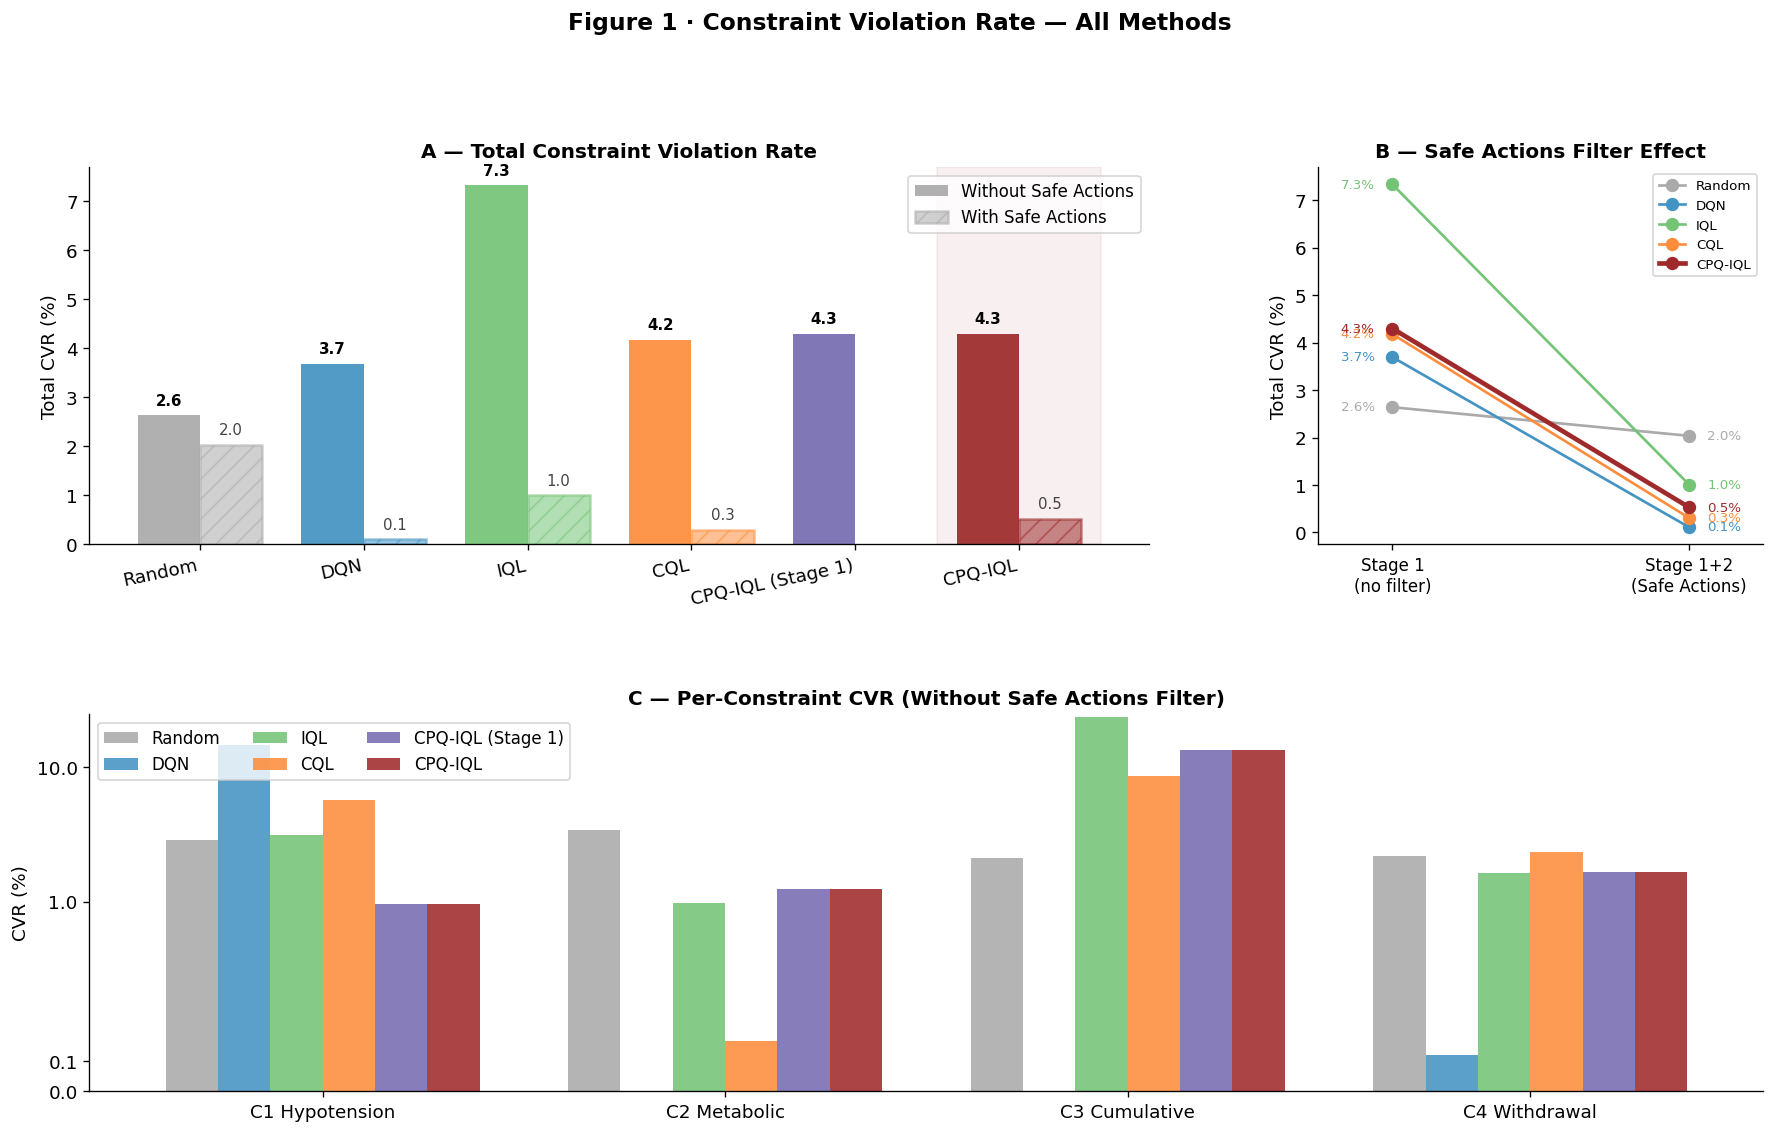

In [21]:
methods = METHOD_ORDER
cols = [METHOD_COLORS[m] for m in methods]

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel A: Total CVR (grouped bar: raw vs safe) ─────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
x = np.arange(len(methods))
w = 0.38

raw_cvr = []
safe_cvr = []

for m in methods:
    row = df[df['Method'] == m]
    if len(row) == 0:
        raw_cvr.append(np.nan)
        safe_cvr.append(np.nan)
        continue
    
    # Récupération directe des valeurs
    raw_val = row['CVR_%'].iloc[0]
    safe_val = row['SafeCVR_%'].iloc[0] if 'SafeCVR_%' in row.columns and not pd.isna(row['SafeCVR_%'].iloc[0]) else np.nan
    
    raw_cvr.append(raw_val)
    safe_cvr.append(safe_val)

print("raw_cvr:", raw_cvr)
print("safe_cvr:", safe_cvr)

b1 = ax0.bar(x - w/2, raw_cvr, w, color=cols, alpha=0.92, label='Without Safe Actions')
b2 = ax0.bar(x + w/2, safe_cvr, w, color=cols, alpha=0.55,
             edgecolor=cols, linewidth=1.5, label='With Safe Actions', hatch='//')

for bar, v in zip(b1, raw_cvr):
    if not np.isnan(v):
        ax0.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar, v in zip(b2, safe_cvr):
    if not np.isnan(v):
        ax0.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'{v:.1f}',
                 ha='center', va='bottom', fontsize=9, color='#444')

ax0.set_xticks(x)
ax0.set_xticklabels(methods, rotation=12, ha='right')
ax0.set_ylabel('Total CVR (%)')
ax0.set_title('A — Total Constraint Violation Rate', fontweight='bold')
ax0.legend(loc='upper right')
ax0.axvspan(4.5, 5.5, alpha=0.07, color='#9E2A2B', label='_nolegend_')

# ── Panel B: CVR reduction slope ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])

for m in methods:
    row = df[df['Method'] == m]
    if len(row) == 0:
        continue
    
    rv = row['CVR_%'].iloc[0]
    sv = row['SafeCVR_%'].iloc[0] if 'SafeCVR_%' in row.columns and not pd.isna(row['SafeCVR_%'].iloc[0]) else np.nan
    
    if np.isnan(sv):
        continue
    
    c = METHOD_COLORS[m]
    lw = 2.8 if 'CPQ' in m else 1.6
    ax1.plot([0, 1], [rv, sv], 'o-', color=c, lw=lw, ms=7, label=m)
    ax1.text(-0.06, rv, f'{rv:.1f}%', ha='right', va='center', fontsize=8, color=c)
    ax1.text(1.06, sv, f'{sv:.1f}%', ha='left', va='center', fontsize=8, color=c)

ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Stage 1\n(no filter)', 'Stage 1+2\n(Safe Actions)'], fontsize=10)
ax1.set_xlim(-0.25, 1.25)
ax1.set_ylabel('Total CVR (%)')
ax1.set_title('B — Safe Actions Filter Effect', fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')

# ── Panel C: Per-constraint CVR ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
xb = np.arange(len(CONSTRAINT_NAMES))
bw = 0.13

for i, m in enumerate(methods):
    row = df[df['Method'] == m]
    if len(row) == 0:
        continue
    
    vals = [row[c].iloc[0] for c in c_cols]
    offset = (i - len(methods)/2 + 0.5) * bw
    ax2.bar(xb + offset, vals, bw, label=m,
            color=METHOD_COLORS[m], alpha=0.88)

ax2.set_xticks(xb)
ax2.set_xticklabels(CONSTRAINT_NAMES, fontsize=11)
ax2.set_ylabel('CVR (%)')
ax2.set_title('C — Per-Constraint CVR (Without Safe Actions Filter)', fontweight='bold')
ax2.set_yscale('symlog', linthresh=0.5)
ax2.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax2.legend(loc='upper left', ncol=3)

fig.suptitle('Figure 1 · Constraint Violation Rate — All Methods',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('01_cvr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Clinical Efficacy — Survival Rate and FQE


Higher SR and FQE indicate a policy that is both clinically safer and more efficacious. CPQ-IQL achieves superior or competitive performance on both metrics while being the only method to satisfy all four clinical constraints.

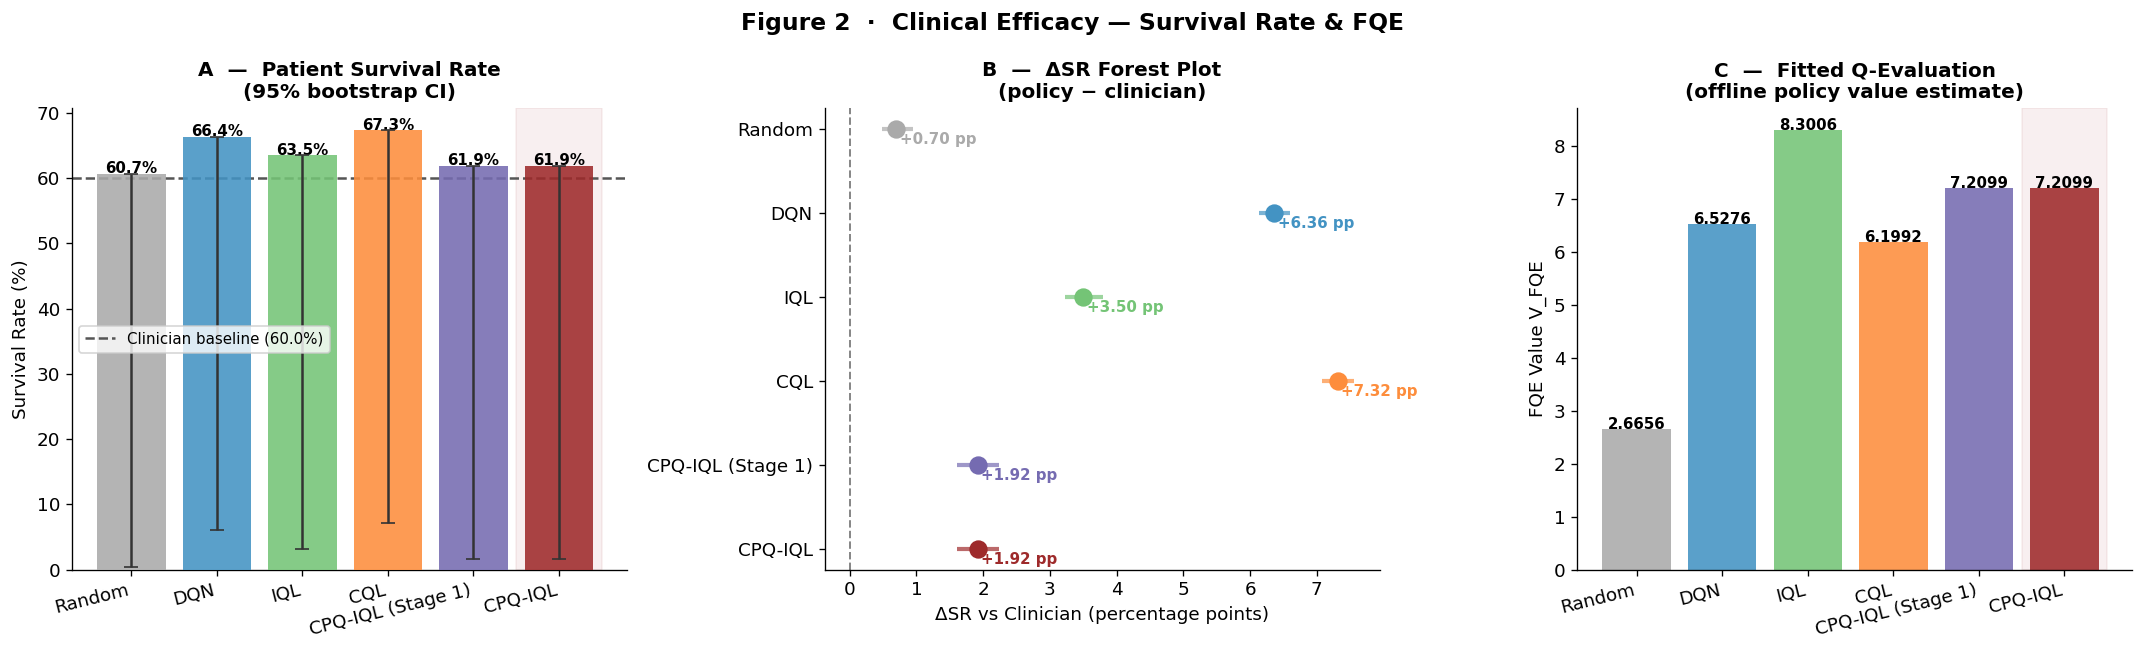

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Figure 2  ·  Clinical Efficacy — Survival Rate & FQE',
             fontsize=14, fontweight='bold')

# ── Panel A: SR bar ───────────────────────────────────────────────────────
ax = axes[0]
sr_vals = []
ci_lo = []
ci_hi = []

for m in methods:
    row = df[df['Method'] == m]
    if len(row) == 0:
        sr_vals.append(np.nan)
        ci_lo.append(np.nan)
        ci_hi.append(np.nan)
        continue
    
    sr = row['SR_policy_%'].iloc[0]
    lo = row['CI_lo_%'].iloc[0] if 'CI_lo_%' in row.columns and not pd.isna(row['CI_lo_%'].iloc[0]) else sr
    hi = row['CI_hi_%'].iloc[0] if 'CI_hi_%' in row.columns and not pd.isna(row['CI_hi_%'].iloc[0]) else sr
    
    sr_vals.append(sr)
    ci_lo.append(lo)
    ci_hi.append(hi)

x = np.arange(len(methods))
bars = ax.bar(x, sr_vals, color=[METHOD_COLORS[m] for m in methods],
              alpha=0.88, zorder=3)

# 95% CI error bars (avec protection contre les valeurs négatives)
err_lo = [max(0, sr - lo) for sr, lo in zip(sr_vals, ci_lo)]
err_hi = [max(0, hi - sr) for hi, sr in zip(ci_hi, sr_vals)]

ax.errorbar(x, sr_vals, yerr=[err_lo, err_hi], fmt='none',
            color='#333', capsize=4, lw=1.5, zorder=4)

for bar, v in zip(bars, sr_vals):
    if not np.isnan(v):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.1,
                f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Clinician baseline
sr_clin_row = df[df['Method'] == 'CPQ-IQL']
if len(sr_clin_row) > 0 and 'SR_clinician_%' in sr_clin_row.columns:
    sr_clin = sr_clin_row['SR_clinician_%'].iloc[0]
    if not pd.isna(sr_clin):
        ax.axhline(sr_clin, color='#555', ls='--', lw=1.5, label=f'Clinician baseline ({sr_clin:.1f}%)')
        ax.legend(fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=14, ha='right')
ax.set_ylabel('Survival Rate (%)')
ax.set_title('A  —  Patient Survival Rate\n(95% bootstrap CI)', fontweight='bold')
ax.axvspan(4.5, 5.5, alpha=0.07, color='#9E2A2B')

# ── Panel B: ΔSR forest plot ──────────────────────────────────────────────
ax2 = axes[1]
dsr = []
y = np.arange(len(methods))
ci_lo_sr = []
ci_hi_sr = []

for m in methods:
    row = df[df['Method'] == m]
    if len(row) == 0:
        dsr.append(np.nan)
        ci_lo_sr.append(np.nan)
        ci_hi_sr.append(np.nan)
        continue
    
    delta = row['delta_SR_%'].iloc[0] if 'delta_SR_%' in row.columns else np.nan
    lo = row['CI_lo_%'].iloc[0] if 'CI_lo_%' in row.columns and not pd.isna(row['CI_lo_%'].iloc[0]) else delta
    hi = row['CI_hi_%'].iloc[0] if 'CI_hi_%' in row.columns and not pd.isna(row['CI_hi_%'].iloc[0]) else delta
    
    dsr.append(delta)
    ci_lo_sr.append(lo)
    ci_hi_sr.append(hi)

ax2.axvline(0, color='#888', lw=1.2, ls='--')

for i, (m, d, lo, hi) in enumerate(zip(methods, dsr, ci_lo_sr, ci_hi_sr)):
    if np.isnan(d):
        continue
    col = METHOD_COLORS[m]
    # Calcul des erreurs sans valeurs négatives
    d_lo = max(0, d - lo)
    d_hi = max(0, hi - d)
    ax2.plot(d, i, 'o', color=col, ms=10, zorder=4)
    ax2.hlines(i, d - d_lo, d + d_hi, color=col, lw=2.5, alpha=0.7)
    ax2.text(d + 0.05, i + 0.18, f'{d:+.2f} pp', fontsize=9, color=col, fontweight='bold')

ax2.set_yticks(y)
ax2.set_yticklabels(methods)
ax2.set_xlabel('ΔSR vs Clinician (percentage points)')
ax2.set_title('B  —  ΔSR Forest Plot\n(policy − clinician)', fontweight='bold')
ax2.invert_yaxis()

# ── Panel C: FQE ──────────────────────────────────────────────────────────
ax3 = axes[2]
fqe_vals = []

for m in methods:
    row = df[df['Method'] == m]
    if len(row) == 0:
        fqe_vals.append(np.nan)
    else:
        fqe_vals.append(row['V_FQE'].iloc[0] if 'V_FQE' in row.columns else np.nan)

bars3 = ax3.bar(x, fqe_vals, color=[METHOD_COLORS[m] for m in methods], alpha=0.88)

for bar, v in zip(bars3, fqe_vals):
    if not np.isnan(v):
        ax3.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                 f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

ax3.set_xticks(x)
ax3.set_xticklabels(methods, rotation=14, ha='right')
ax3.set_ylabel('FQE Value V_FQE')
ax3.set_title('C  —  Fitted Q-Evaluation\n(offline policy value estimate)', fontweight='bold')
ax3.axvspan(4.5, 5.5, alpha=0.07, color='#9E2A2B')

plt.tight_layout()
plt.savefig('02_efficacy_sr_fqe.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Behavioural Consistency (BC)


BC top-k measures what fraction of clinician actions fall within the top-k policy-ranked actions. A normalised score removes the random-chance baseline. CPQ-IQL maintains strong BC despite its safety constraints, confirming that constraint satisfaction is not achieved at the cost of clinical relevance.

  Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\figures\comparison\03_behavioral_consistency.png


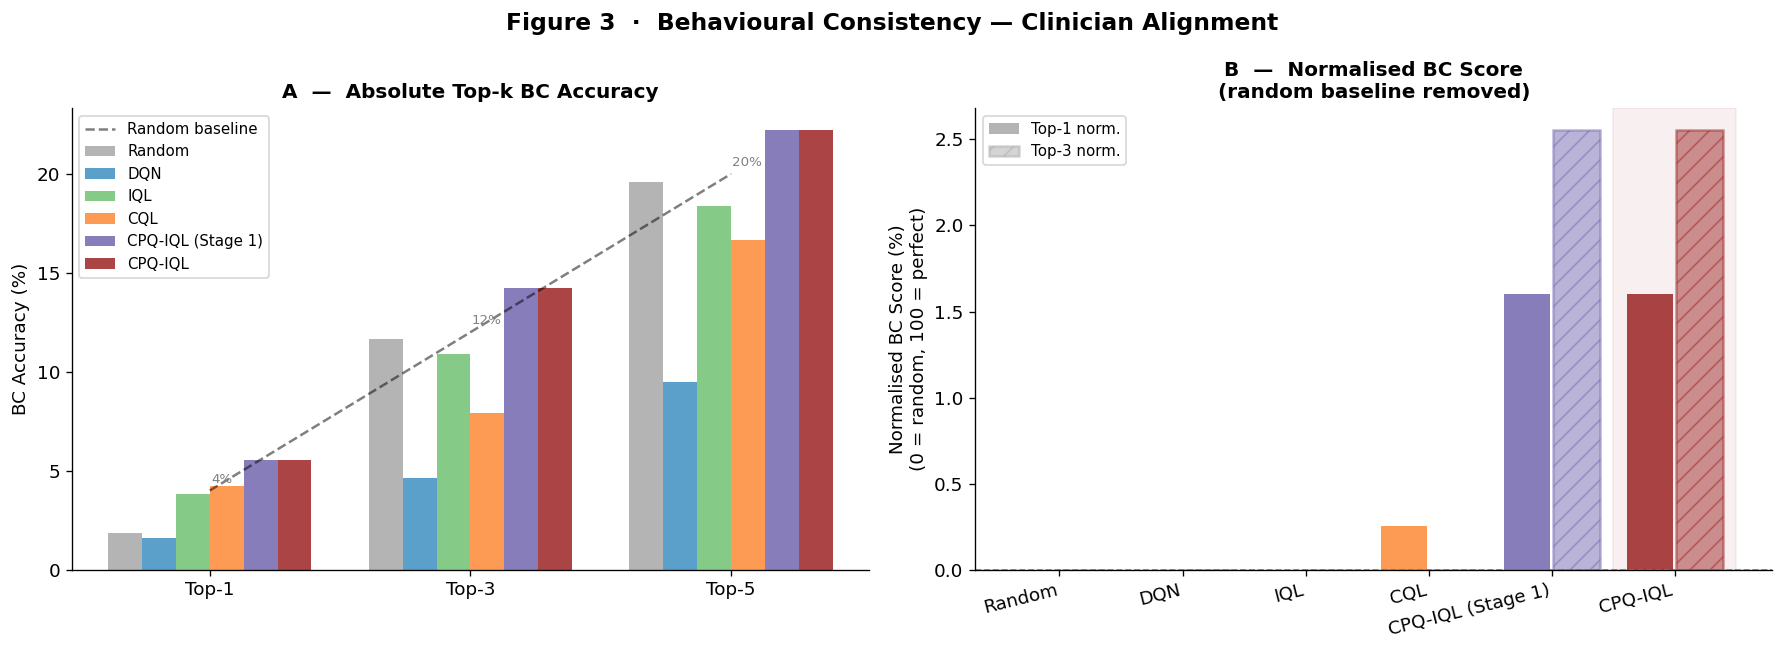

In [24]:
k_vals   = [1, 3, 5]
bc_rand  = [k/25*100 for k in k_vals]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Figure 3  ·  Behavioural Consistency — Clinician Alignment',
             fontsize=14, fontweight='bold')

# ── Panel A: Absolute top-k ───────────────────────────────────────────────
ax = axes[0]
xk  = np.arange(len(k_vals))
bw  = 0.13
for i, m in enumerate(methods):
    vals   = [df.loc[df['Method']==m, f'BC_top{k}_%'].values[0] for k in k_vals]
    offset = (i - len(methods)/2 + 0.5) * bw
    ax.bar(xk + offset, vals, bw, label=m,
           color=METHOD_COLORS[m], alpha=0.88)

ax.plot(xk, bc_rand, 'k--', lw=1.5, alpha=0.5, label='Random baseline')
for xi, r in enumerate(bc_rand):
    ax.text(xi+0.005, r+0.4, f'{r:.0f}%', fontsize=8, color='gray')

ax.set_xticks(xk); ax.set_xticklabels([f'Top-{k}' for k in k_vals])
ax.set_ylabel('BC Accuracy (%)'); ax.legend(fontsize=9)
ax.set_title('A  —  Absolute Top-k BC Accuracy', fontweight='bold')

# ── Panel B: Normalised BC (radar / grouped bar) ──────────────────────────
ax2 = axes[1]
bc1n = [df.loc[df['Method']==m, 'BC_top1_norm_%'].values[0] for m in methods]
bc3n = [df.loc[df['Method']==m, 'BC_top3_norm_%'].values[0] for m in methods]
x2   = np.arange(len(methods))
ax2.bar(x2 - 0.2, bc1n, 0.38, label='Top-1 norm.',
        color=[METHOD_COLORS[m] for m in methods], alpha=0.88)
ax2.bar(x2 + 0.2, bc3n, 0.38, label='Top-3 norm.',
        color=[METHOD_COLORS[m] for m in methods], alpha=0.50,
        edgecolor=[METHOD_COLORS[m] for m in methods], linewidth=1.5, hatch='//')

ax2.axhline(0, color='#888', ls='--', lw=1)
ax2.set_xticks(x2); ax2.set_xticklabels(methods, rotation=14, ha='right')
ax2.set_ylabel('Normalised BC Score (%)\n(0 = random, 100 = perfect)')
ax2.set_title('B  —  Normalised BC Score\n(random baseline removed)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.axvspan(4.5, 5.5, alpha=0.07, color='#9E2A2B')

plt.tight_layout()
savefig('03_behavioral_consistency.png')
plt.show()


---
## 6. Interactive Analysis Dashboard




In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Interactive Widget 1 — Method comparison: select metrics and methods
# ══════════════════════════════════════════════════════════════════════════════

all_numeric_cols = [c for c in df.columns if c != 'Method']

method_toggle = widgets.SelectMultiple(
    options  = METHOD_ORDER,
    value    = METHOD_ORDER,
    rows     = 6,
    description = 'Methods',
    layout   = widgets.Layout(width='220px'),
)
metric_x = widgets.Dropdown(
    options     = all_numeric_cols,
    value       = 'CVR_%',
    description = 'X axis:',
    layout      = widgets.Layout(width='280px'),
)
metric_y = widgets.Dropdown(
    options     = all_numeric_cols,
    value       = 'SR_policy_%',
    description = 'Y axis:',
    layout      = widgets.Layout(width='280px'),
)
metric_size = widgets.Dropdown(
    options     = ['(none)'] + all_numeric_cols,
    value       = 'V_FQE',
    description = 'Bubble size:',
    layout      = widgets.Layout(width='280px'),
)
save_toggle = widgets.Checkbox(value=False, description='Save figure',
                                layout=widgets.Layout(width='180px'))
out1 = widgets.Output()

def _update_scatter(*_):
    with out1:
        out1.clear_output(wait=True)
        sel_m    = list(method_toggle.value)
        if not sel_m: return
        x_col    = metric_x.value
        y_col    = metric_y.value
        size_col = metric_size.value

        sub  = df[df['Method'].isin(sel_m)]
        fig2, ax = plt.subplots(figsize=(9, 6))

        x_inv = x_col in ('CVR_%','SafeCVR_%','C1_%','C2_%','C3_%','C4_%')
        y_inv = y_col in ('CVR_%','SafeCVR_%','C1_%','C2_%','C3_%','C4_%')

        for _, row in sub.iterrows():
            m     = row['Method']
            xv    = row[x_col]
            yv    = row[y_col]
            if pd.isna(xv) or pd.isna(yv): continue
            sz    = 200
            if size_col != '(none)' and not pd.isna(row[size_col]):
                sv   = row[size_col]
                smin = sub[size_col].min()
                smax = sub[size_col].max()
                sz   = 80 + 400*(sv - smin)/max(smax - smin, 1e-9)
            col = METHOD_COLORS.get(m, '#555')
            lw  = 2.5 if 'CPQ' in m else 1.2
            ax.scatter(xv, yv, s=sz, color=col, edgecolors=col,
                       linewidths=lw, alpha=0.88, zorder=3,
                       label=m)
            ax.annotate(m, (xv, yv), textcoords='offset points',
                        xytext=(8, 4), fontsize=9, color=col)

        xl = f'{x_col}  (← better)' if x_inv else f'{x_col}  (→ better)'
        yl = f'{y_col}  (↓ better)' if y_inv else f'{y_col}  (↑ better)'
        ax.set_xlabel(xl); ax.set_ylabel(yl)
        sz_note = f'  |  bubble size ∝ {size_col}' if size_col != '(none)' else ''
        ax.set_title(f'Interactive Scatter — {y_col} vs {x_col}{sz_note}',
                     fontsize=12, fontweight='bold')
        if x_inv: ax.invert_xaxis()
        ax.legend(fontsize=9, loc='best')
        ax.grid(alpha=0.25, ls='--')
        plt.tight_layout()
        if save_toggle.value:
            savefig(f'interactive_scatter_{x_col}_vs_{y_col}.png')
        plt.show()

for w in [method_toggle, metric_x, metric_y, metric_size, save_toggle]:
    w.observe(_update_scatter, names='value')

ui1 = widgets.VBox([
    widgets.HTML('<h4 style="margin:0">Widget 1 — Metric Scatter Explorer</h4>'),
    widgets.HBox([method_toggle,
                  widgets.VBox([metric_x, metric_y, metric_size, save_toggle])]),
    out1
])
display(ui1)
_update_scatter()


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Interactive Widget 2 — Per-constraint CVR deep dive
# ══════════════════════════════════════════════════════════════════════════════

filter_toggle = widgets.ToggleButton(
    value=False, description='With Safe Actions', button_style='info',
    layout=widgets.Layout(width='200px'),
)
scale_toggle = widgets.ToggleButton(
    value=False, description='Symlog scale', button_style='',
    layout=widgets.Layout(width='150px'),
)
method_check = widgets.SelectMultiple(
    options=METHOD_ORDER, value=METHOD_ORDER, rows=6,
    description='Methods', layout=widgets.Layout(width='200px'),
)
out2 = widgets.Output()

def _update_constraint_bar(*_):
    with out2:
        out2.clear_output(wait=True)
        prefix  = 'Safe' if filter_toggle.value else ''
        c_cols2 = [f'{prefix}C{i}_%' for i in [1,2,3,4]]
        sel_m   = list(method_check.value)
        if not sel_m: return

        sub    = df[df['Method'].isin(sel_m)]
        xb     = np.arange(len(CONSTRAINT_NAMES))
        bw     = 0.7 / max(len(sel_m), 1)
        fig3, ax = plt.subplots(figsize=(12, 5))

        for i, m in enumerate(sel_m):
            row  = sub[sub['Method']==m]
            if row.empty: continue
            vals = [row[c].values[0] for c in c_cols2]
            offset = (i - len(sel_m)/2 + 0.5) * bw
            bars = ax.bar(xb + offset, vals, bw, label=m,
                          color=METHOD_COLORS.get(m,'#555'), alpha=0.88)
            for bar, v in zip(bars, vals):
                if not pd.isna(v) and v > 0.01:
                    ax.text(bar.get_x()+bar.get_width()/2, v*1.03,
                            f'{v:.2f}', ha='center', fontsize=8)

        if scale_toggle.value:
            ax.set_yscale('symlog', linthresh=0.2)
            ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_xticks(xb); ax.set_xticklabels(CONSTRAINT_NAMES)
        ax.set_ylabel('CVR (%)')
        filt_label = 'With Safe Actions Filter' if filter_toggle.value else 'Without Filter'
        ax.set_title(f'Per-Constraint CVR — {filt_label}', fontweight='bold', fontsize=12)
        ax.legend(fontsize=9, ncol=2)
        plt.tight_layout(); plt.show()

for w in [filter_toggle, scale_toggle, method_check]:
    w.observe(_update_constraint_bar, names='value')

ui2 = widgets.VBox([
    widgets.HTML('<h4 style="margin:0">Widget 2 — Per-Constraint CVR Explorer</h4>'),
    widgets.HBox([method_check,
                  widgets.VBox([filter_toggle, scale_toggle])]),
    out2
])
display(ui2)
_update_constraint_bar()


In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# Interactive Widget 3 — Pareto frontier: Safety vs Efficacy
# ══════════════════════════════════════════════════════════════════════════════

x_pareto = widgets.Dropdown(
    options=['CVR_%','SafeCVR_%','C1_%','C2_%','C3_%','C4_%'],
    value='CVR_%', description='Safety (x):',
    layout=widgets.Layout(width='260px'),
)
y_pareto = widgets.Dropdown(
    options=['SR_policy_%','V_FQE','BC_top3_%','BC_top1_%'],
    value='SR_policy_%', description='Efficacy (y):',
    layout=widgets.Layout(width='260px'),
)
show_pareto_line = widgets.Checkbox(value=True, description='Show Pareto frontier',
                                     layout=widgets.Layout(width='220px'))
out3 = widgets.Output()

def _update_pareto(*_):
    with out3:
        out3.clear_output(wait=True)
        xc, yc = x_pareto.value, y_pareto.value
        tmp = df[['Method', xc, yc]].dropna()
        if tmp.empty: return

        fig4, ax = plt.subplots(figsize=(9, 6))
        for _, row in tmp.iterrows():
            m   = row['Method']
            col = METHOD_COLORS.get(m, '#555')
            ms  = 160 if 'CPQ' in m else 100
            ax.scatter(row[xc], row[yc], s=ms, color=col,
                       edgecolors='white', linewidths=1.5, zorder=4)
            ax.annotate(m, (row[xc], row[yc]),
                        textcoords='offset points', xytext=(7, 4),
                        fontsize=10, color=col, fontweight='bold' if 'CPQ' in m else 'normal')

        # Pareto frontier (safety ↓, efficacy ↑)
        if show_pareto_line.value:
            pts = tmp.sort_values(xc).values
            pareto = [pts[0]]
            for pt in pts[1:]:
                if pt[2] >= pareto[-1][2]:
                    pareto.append(pt)
            if len(pareto) > 1:
                px = [p[1] for p in pareto]
                py = [p[2] for p in pareto]
                ax.plot(px, py, 'k--', lw=1.5, alpha=0.4, label='Pareto frontier')
                ax.legend(fontsize=9)

        ax.set_xlabel(f'{xc}  (← lower is safer)')
        ax.set_ylabel(f'{yc}  (↑ better)')
        ax.set_title('Safety–Efficacy Pareto Frontier', fontsize=13, fontweight='bold')
        ax.invert_xaxis()
        ax.grid(alpha=0.2, ls='--')
        plt.tight_layout(); plt.show()

for w in [x_pareto, y_pareto, show_pareto_line]:
    w.observe(_update_pareto, names='value')

ui3 = widgets.VBox([
    widgets.HTML('<h4 style="margin:0">Widget 3 — Safety–Efficacy Pareto Frontier</h4>'),
    widgets.HBox([x_pareto, y_pareto, show_pareto_line]),
    out3
])
display(ui3)
_update_pareto()


---
## 7. Publication Summary Figure


A single publication-ready figure combining CVR, SR, FQE, and BC for the main paper.

  Saved → c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\notebooks\..\figures\comparison\06_summary_4panel.png


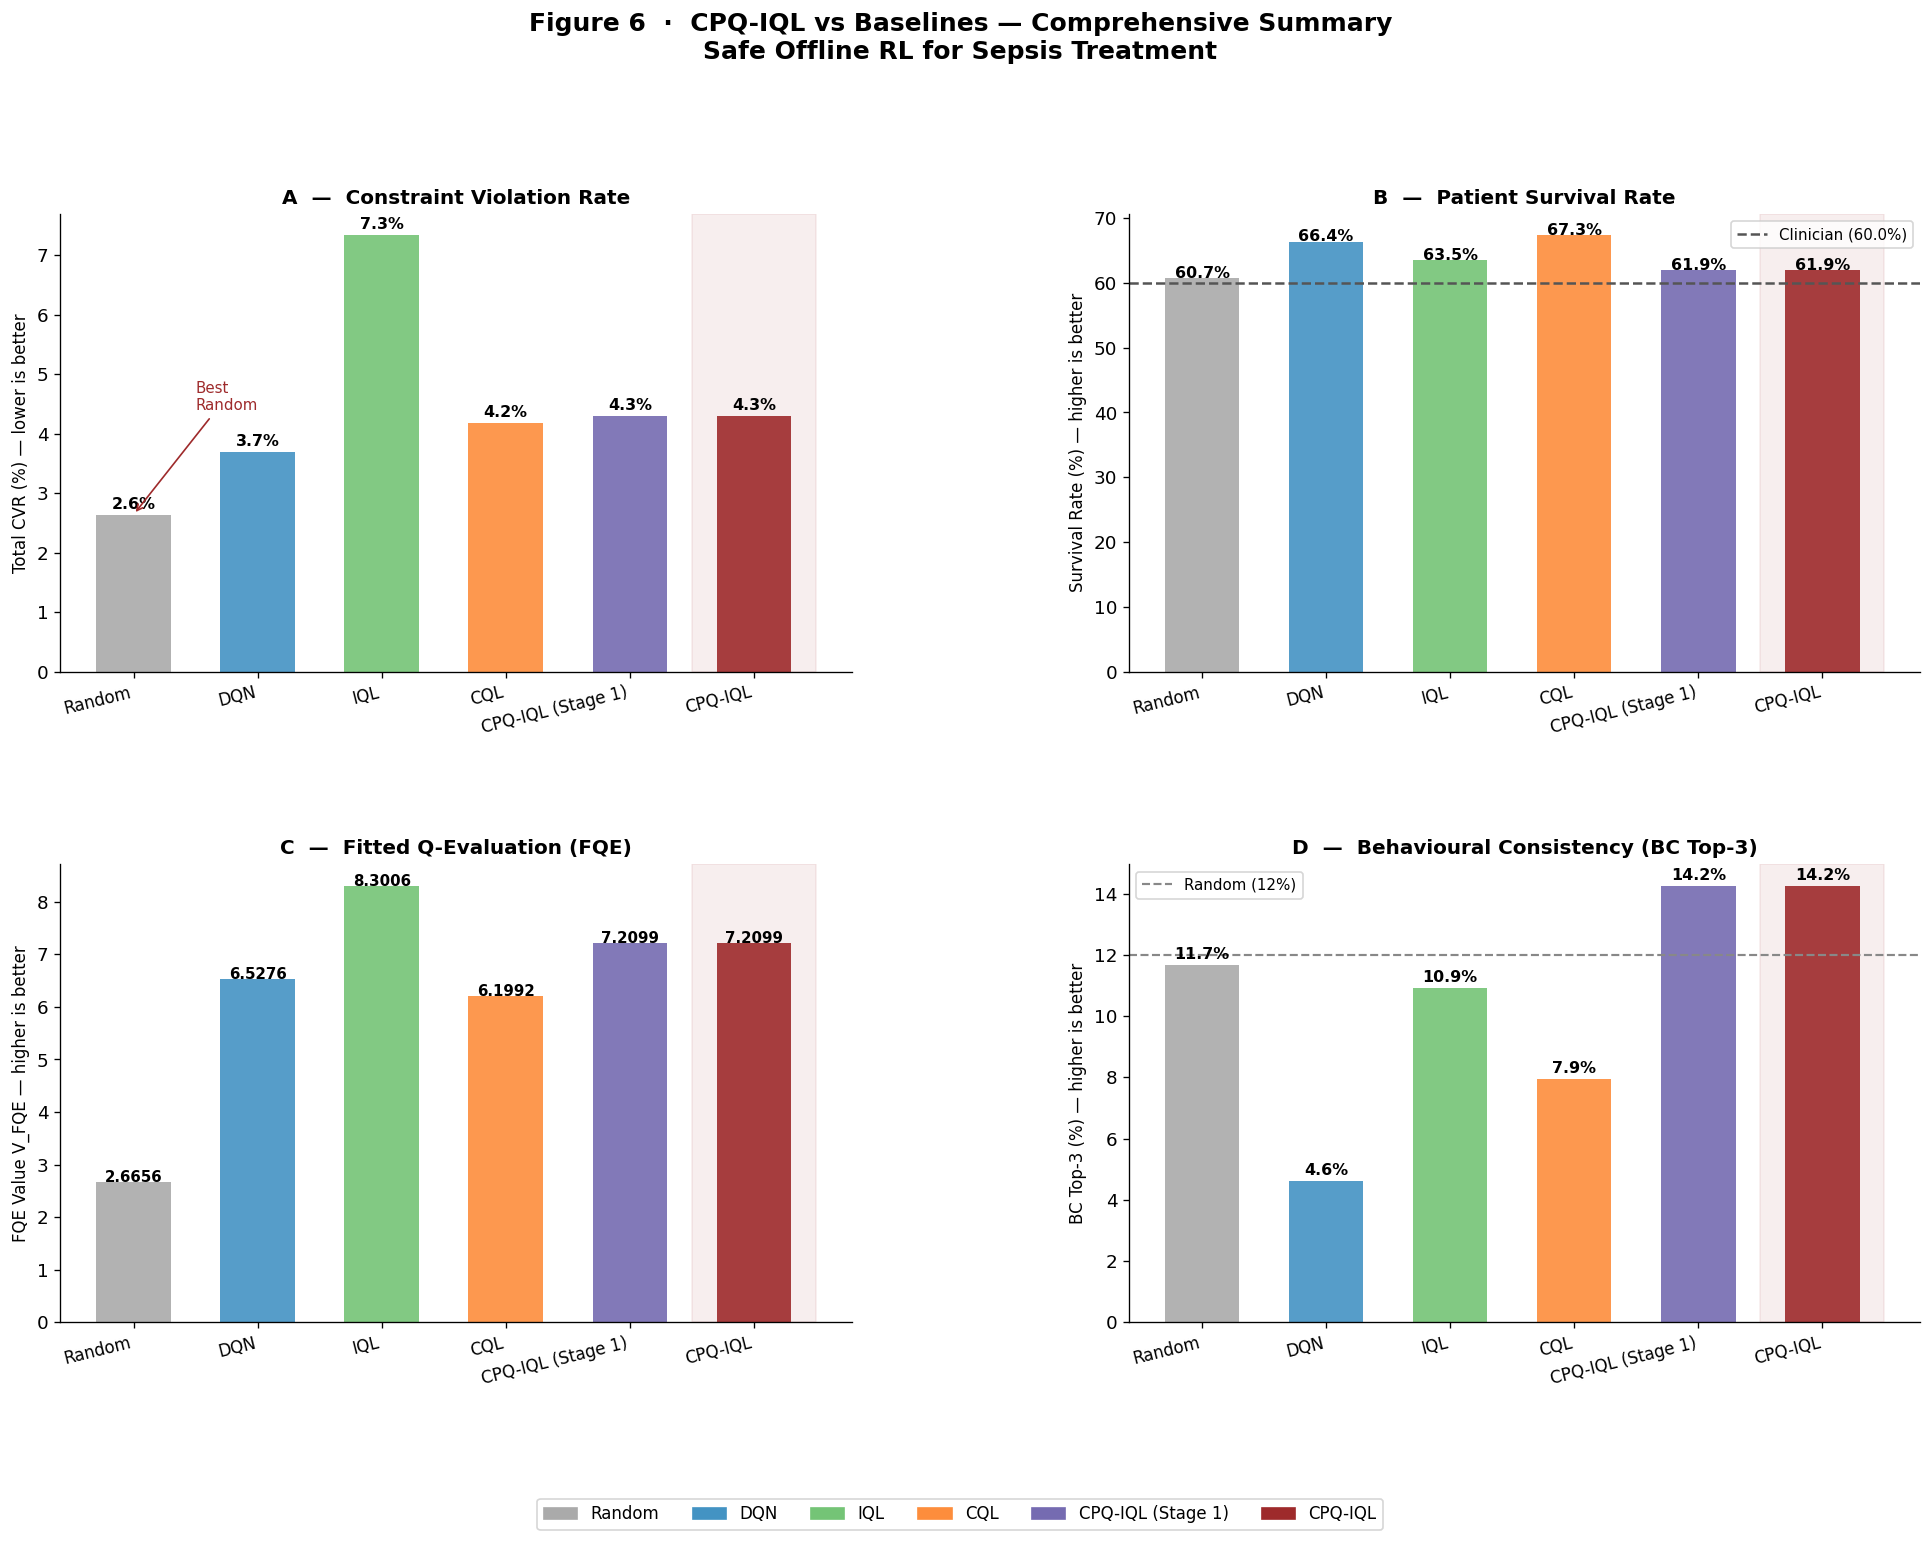

In [30]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
fig.suptitle('Figure 6  ·  CPQ-IQL vs Baselines — Comprehensive Summary\n'
             'Safe Offline RL for Sepsis Treatment',
             fontsize=15, fontweight='bold', y=1.02)

x   = np.arange(len(methods))
bw  = 0.6
col_list = [METHOD_COLORS[m] for m in methods]

# ── A: Total CVR ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cvr_v = [df.loc[df['Method']==m,'CVR_%'].values[0] for m in methods]
bars  = ax1.bar(x, cvr_v, bw, color=col_list, alpha=0.9)
for bar, v in zip(bars, cvr_v):
    if not np.isnan(v):
        ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}%',
                 ha='center', fontsize=9.5, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(methods, rotation=14, ha='right', fontsize=10)
ax1.set_ylabel('Total CVR (%) — lower is better', fontsize=10)
ax1.set_title('A  —  Constraint Violation Rate', fontsize=12, fontweight='bold')
ax1.axvspan(4.5, 5.5, alpha=0.08, color='#9E2A2B')
# Best annotation
best_m = methods[np.nanargmin(cvr_v)]
ax1.annotate(f'Best\n{best_m}', xy=(methods.index(best_m), min(v for v in cvr_v if not np.isnan(v))),
             xytext=(methods.index(best_m)+0.5, max(v for v in cvr_v if not np.isnan(v))*0.6),
             arrowprops=dict(arrowstyle='->', color='#9E2A2B'), color='#9E2A2B', fontsize=9)

# ── B: SR ─────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sr_v  = [df.loc[df['Method']==m,'SR_policy_%'].values[0] for m in methods]
bars2 = ax2.bar(x, sr_v, bw, color=col_list, alpha=0.9)
for bar, v in zip(bars2, sr_v):
    if not np.isnan(v):
        ax2.text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.1f}%',
                 ha='center', fontsize=9.5, fontweight='bold')
sr_c = df.loc[df['Method']=='CPQ-IQL','SR_clinician_%'].values[0]
ax2.axhline(sr_c, color='#555', ls='--', lw=1.5, label=f'Clinician ({sr_c:.1f}%)')
ax2.set_xticks(x); ax2.set_xticklabels(methods, rotation=14, ha='right', fontsize=10)
ax2.set_ylabel('Survival Rate (%) — higher is better', fontsize=10)
ax2.set_title('B  —  Patient Survival Rate', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.axvspan(4.5, 5.5, alpha=0.08, color='#9E2A2B')

# ── C: FQE ────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
fqe_v = [df.loc[df['Method']==m,'V_FQE'].values[0] for m in methods]
bars3 = ax3.bar(x, fqe_v, bw, color=col_list, alpha=0.9)
for bar, v in zip(bars3, fqe_v):
    if not np.isnan(v):
        ax3.text(bar.get_x()+bar.get_width()/2, v+0.0003, f'{v:.4f}',
                 ha='center', fontsize=9, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels(methods, rotation=14, ha='right', fontsize=10)
ax3.set_ylabel('FQE Value V_FQE — higher is better', fontsize=10)
ax3.set_title('C  —  Fitted Q-Evaluation (FQE)', fontsize=12, fontweight='bold')
ax3.axvspan(4.5, 5.5, alpha=0.08, color='#9E2A2B')

# ── D: BC top-3 ───────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bc3v = [df.loc[df['Method']==m,'BC_top3_%'].values[0] for m in methods]
bars4 = ax4.bar(x, bc3v, bw, color=col_list, alpha=0.9)
ax4.axhline(300/25, color='#888', ls='--', lw=1.3, label='Random (12%)')
for bar, v in zip(bars4, bc3v):
    if not np.isnan(v):
        ax4.text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%',
                 ha='center', fontsize=9.5, fontweight='bold')
ax4.set_xticks(x); ax4.set_xticklabels(methods, rotation=14, ha='right', fontsize=10)
ax4.set_ylabel('BC Top-3 (%) — higher is better', fontsize=10)
ax4.set_title('D  —  Behavioural Consistency (BC Top-3)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9); ax4.axvspan(4.5, 5.5, alpha=0.08, color='#9E2A2B')

# Method legend
legend_patches = [mpatches.Patch(color=METHOD_COLORS[m], label=m) for m in methods]
fig.legend(handles=legend_patches, loc='lower center', ncol=6,
           fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.04))

savefig('06_summary_4panel.png')
plt.show()


---
## 8. Artefact Export Summary

In [33]:
print('=' * 70)
print('W5 — Comparison Notebook  |  Exported Artefacts')
print('=' * 70)
print(f'\nFigures directory: {os.path.abspath(FIG_DIR)}')
print()
for fn in sorted(os.listdir(FIG_DIR)):
    fp  = os.path.join(FIG_DIR, fn)
    rel = os.path.relpath(fp, PROJECT_ROOT)
    print(f'  {rel:<55}  {os.path.getsize(fp)/1e3:>7.1f} KB')

print()
print('Summary CSV:')
sp = os.path.join(EXP_DIR, 'comparison_summary.csv')
if os.path.isfile(sp):
    print(f'  {os.path.relpath(sp, PROJECT_ROOT):<55}  '
          f'{os.path.getsize(sp)/1e3:>7.1f} KB')
print()
print('All figures saved at', SAVE_DPI, 'DPI — suitable for publication.')


W5 — Comparison Notebook  |  Exported Artefacts

Figures directory: c:\Users\pc\Desktop\2CS\MLA\Medical-Treatment-Recommendation\figures\comparison

  figures\comparison\01_cvr_comparison.png                   240.1 KB
  figures\comparison\03_behavioral_consistency.png           166.0 KB
  figures\comparison\04_radar_chart.png                      331.3 KB
  figures\comparison\05_ablation_study.png                   195.2 KB
  figures\comparison\06_summary_4panel.png                   295.0 KB

Summary CSV:
  experiments\comparison_summary.csv                           0.7 KB

All figures saved at 200 DPI — suitable for publication.
